In [2]:
import pandas as pd

In [3]:
housepricing= pd.read_csv("Housing.csv")

In [6]:
housepricing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
housepricing.shape 

(545, 13)

In [25]:
x = housepricing.drop("price", axis=1)
y = housepricing["price"] 

In [13]:
housepricing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [14]:
# There were 0 missing values in the dataset.
#Hence no need for handling missing values using fillna() or dropna() 

In [16]:
housepricing.duplicated().sum() # no duplicate rows

np.int64(0)

In [17]:
housepricing.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [20]:
housepricing = pd.get_dummies(housepricing, drop_first=True)

In [22]:
housepricing.head() # converted the categorical data into numeric

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [23]:
# For price detection all the columns present are reasonable predictors.
# Hence, no column dropped.

In [24]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split( x, y , test_size=0.2, random_state=42) 

In [28]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [29]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
import numpy as np
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [31]:
y_pred = model.predict(x_test)

In [32]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE=", mae)

MAE= 970043.4039201637


In [33]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE=", rmse)

RMSE= 1324506.9600914388


In [34]:
r2= r2_score(y_test,y_pred)
print("R2=", r2)

R2= 0.6529242642153184


In [35]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_model = RandomForestRegressor(random_state=42) 

In [40]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf_pred = rf_model.predict(x_test)

In [50]:
rf_mae = mean_absolute_error(y_test , rf_pred)
print(rf_mae)

1021546.0353211008


In [51]:
rf_mse = np.sqrt(mean_squared_error(y_test , rf_pred))
print(rf_mse)

1400565.9728553821


In [52]:
rf_r2 = r2_score(y_test , rf_pred)
print(rf_r2)

0.611918531405699


In [53]:
print("MAE of linear regression" , mae)
print("MAE of random forest regressor" , rf_mae)

MAE of linear regression 970043.4039201637
MAE of random forest regressor 1021546.0353211008


In [54]:
print("RMSE of linear regression" , rmse)
print("RMSE of random forest regressor" , rf_mse)

RMSE of linear regression 1324506.9600914388
RMSE of random forest regressor 1400565.9728553821


In [55]:
print(" R2 score of linear regression" , r2)
print(" R2 score of random forest regressor " , rf_r2)

 R2 score of linear regression 0.6529242642153184
 R2 score of random forest regressor  0.611918531405699


In [56]:
# As performance of regression model depends on datasets 
# Linear regression was able to attain smaller mae and rmse values and better R2 score compared to random forst regressor
# Hence Linear Regression works better on this dataset 

In [58]:
import matplotlib.pyplot as plt

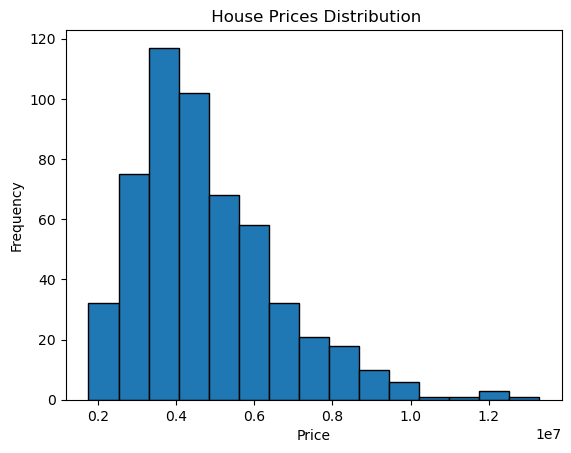

In [61]:
plt.hist(housepricing["price"] , bins=15 , edgecolor="black") 
plt.title(" House Prices Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [62]:
import seaborn as sns

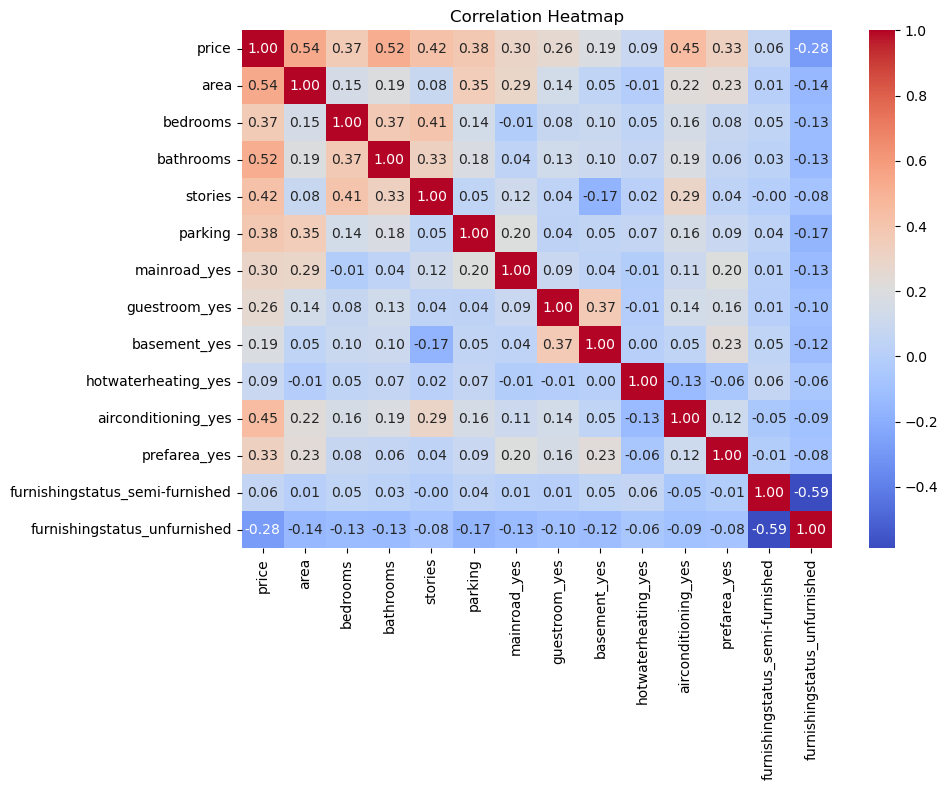

In [64]:
plt.figure(figsize=(10,8))
sns.heatmap(housepricing.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

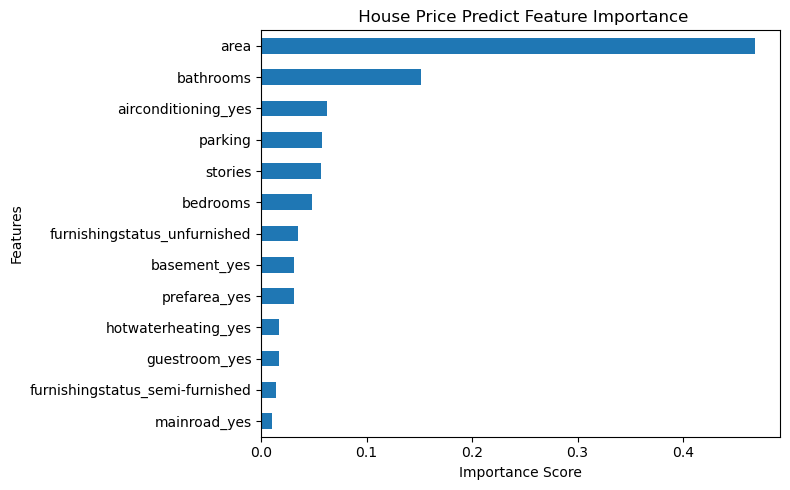

In [69]:
importance = pd.Series(rf_model.feature_importances_, index=x_train.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title(" House Price Predict Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [70]:
# According to my reading the area and bathroom were important features while decinding the house price, as they influenced the pricing alot.

# The linear regression model worked better for this dataset. Thr R2 score calculated by the model was 0.65 i.e. the model was able to explain 65% of how house prices change.

# A surprising observation was that houses with similar numbers of bedrooms often had very different prices. This meant that factors such as area, location preference, and additional amenities may play a bigger role than bedroom count alone.

# Real estate businesses must use data to set property prices of just using old methods.

# The study found that some popular features don't really affect price much.. Where a property is located and its infrastructure do.

# So real estate businesses should focus on promoting and investing in the features that really matter. This way they can make money and price properties more accurately.